# SPiRe

## Spatial Partitioning for Predictive Regimes

Author: Renan Xavier Cortes

----------------------

*SPiRe* (Assunção et al. 2026, ACM SIGSPATIAL) partitions a map into contiguous
regions whose areas share a common **predictive mechanism** $y \approx f_k(x)$,
rather than similar attribute values. For every area, a local model is fitted on
its spatial neighborhood. Neighboring local models are compared through the mean
squared difference of their predictions over a shared reference sample of
predictors. These dissimilarities weight a minimum spanning tree, which is cut
SKATER-style so that each cut minimizes the global error of one regional model
per region.

This tutorial builds a planted example where the predictors carry no
information about the regimes, so attribute-based regionalization cannot find
them, but SPiRe can.

In [1]:
%config InlineBackend.figure_format = "retina"
%load_ext watermark
%watermark

Last updated: 2026-10-07T11:13:48.356691-03:00

Python implementation: CPython
Python version       : 3.14.2
IPython version      : 9.17.1

Compiler    : MSC v.1944 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : Intel64 Family 6 Model 140 Stepping 1, GenuineIntel
CPU cores   : 8
Architecture: 64bit



In [2]:
import geopandas
import libpysal
import matplotlib.pyplot as plt
import numpy
import pandas
from shapely.geometry import box
from sklearn.metrics import adjusted_rand_score

from spopt.region import Skater, Spire

%matplotlib inline
%watermark -w
%watermark -iv

Watermark: 2.6.0

geopandas : 1.2.0
libpysal  : 4.15.0
matplotlib: 3.11.2
numpy     : 2.5.3
pandas    : 3.0.6
shapely   : 2.2.0
sklearn   : 1.9.1
spopt     : 0.8.1.dev1+gf35f7108b



## 1. A planted example

A 20 x 20 grid is split into a top and a bottom half. In both halves the
predictors `x1` and `x2` are drawn from the same distribution, but the response
follows a different mechanism: `y = 2 x1` in the top half and `y = 2 x2` in the
bottom half, plus noise.

In [3]:
rng = numpy.random.default_rng(0)
nrows = ncols = 20
cells = [box(c, -r, c + 1, -r + 1) for r in range(nrows) for c in range(ncols)]
gdf = geopandas.GeoDataFrame(geometry=cells)
gdf["truth"] = (numpy.arange(nrows * ncols) // ncols >= nrows // 2).astype(int)
gdf["x1"] = rng.uniform(-1, 1, len(gdf))
gdf["x2"] = rng.uniform(-1, 1, len(gdf))
signal = numpy.where(gdf["truth"] == 0, 2 * gdf["x1"], 2 * gdf["x2"])
gdf["y"] = signal + rng.normal(0, 0.25 * signal.std(), len(gdf))
w = libpysal.weights.Rook.from_dataframe(gdf, use_index=False)

## 2. Attribute-based regionalization with SKATER

SKATER groups areas with similar values of `x1`, `x2` and `y`, which here are
spatially random.

In [4]:
skater = Skater(gdf, w, ["x1", "x2", "y"], n_clusters=2, floor=10)
skater.solve()
gdf["skater"] = skater.labels_

## 3. Predictive regionalization with SPiRe

We ask for up to six regions and inspect `objective_path_`, the global in-sample
mean squared error after each cut, to choose the number of regions.

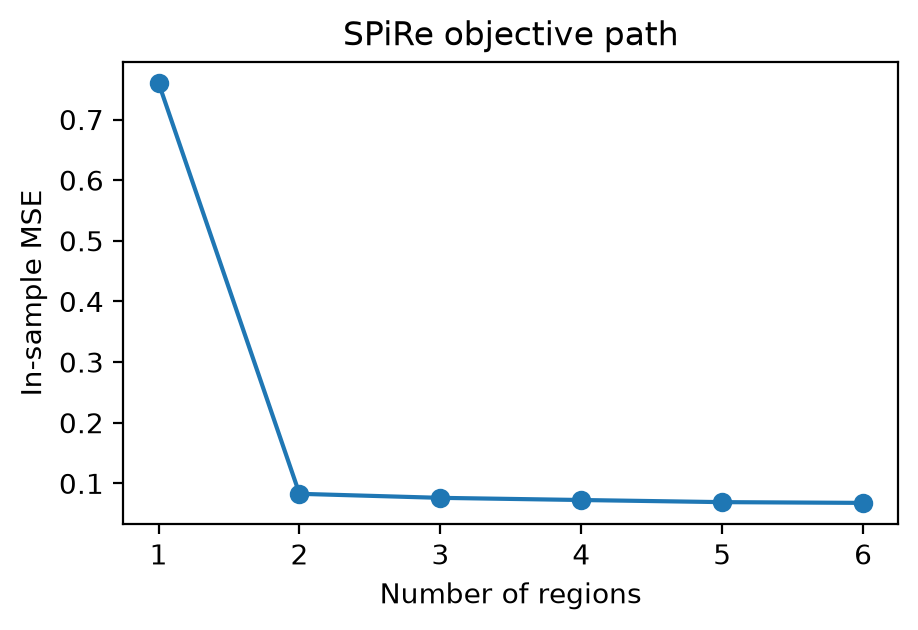

In [5]:
spire = Spire(gdf, w, ["x1", "x2"], "y", n_clusters=6, floor=10, random_state=0)
spire.solve()

fig, ax = plt.subplots(figsize=(5, 3))
n_regions = numpy.arange(1, len(spire.objective_path_) + 1)
ax.plot(n_regions, spire.objective_path_, marker="o")
ax.set_xlabel("Number of regions")
ax.set_ylabel("In-sample MSE")
ax.set_title("SPiRe objective path");

The error drops sharply from one to two regions and flattens afterwards, so we
select two regions from the nested path in `labels_path_`.

skater    0.002256
spire     0.940752
Name: ARI, dtype: float64

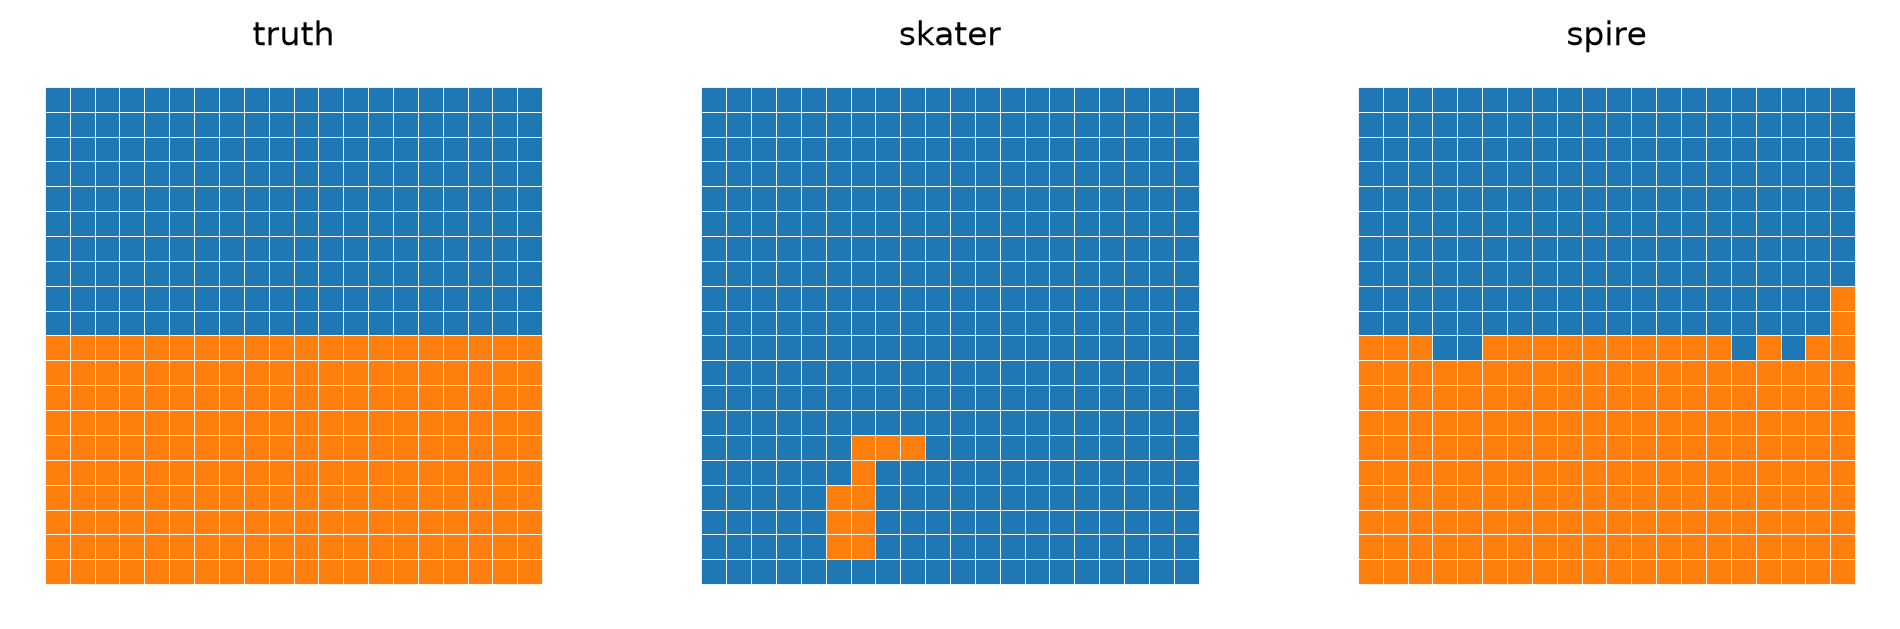

In [6]:
gdf["spire"] = spire.labels_path_[1]

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for ax, column in zip(axs, ["truth", "skater", "spire"], strict=True):
    gdf.plot(column=column, categorical=True, ax=ax, edgecolor="w", linewidth=0.3)
    ax.set_title(column)
    ax.set_axis_off()

pandas.Series(
    {m: adjusted_rand_score(gdf["truth"], gdf[m]) for m in ["skater", "spire"]},
    name="ARI",
)

## 4. Interpreting the regional models

`regional_models_` holds the fitted model of each final region. Solving again
with `n_clusters=2` and the same `random_state` reproduces the two-region
partition, and the regional regression trees show which predictor drives each
regime.

In [7]:
spire2 = Spire(gdf, w, ["x1", "x2"], "y", n_clusters=2, floor=10, random_state=0)
spire2.solve()
pandas.DataFrame(
    {f"region {k}": m.feature_importances_ for k, m in spire2.regional_models_.items()},
    index=["x1", "x2"],
)

,region 0,region 1
x1,1.0,0.0
x2,0.0,1.0


Each region's tree relies almost entirely on a single, different predictor:
SPiRe recovered regions that differ in *how* `y` depends on the predictors,
even though the predictors themselves look the same everywhere.

## 5. Real data: homicide rates in US counties

We now apply SPiRe to the NCOVR data on the 3,085 counties of the continental
United States ([Baller et al. 2001](https://doi.org/10.1111/j.1745-9125.2001.tb00932.x)).
The response is the 1990 county homicide rate (`HR90`), and the predictors are
the 1990 resource deprivation index (`RD90`), population structure index
(`PS90`), unemployment rate (`UE90`), divorce rate (`DV90`) and median age
(`MA90`). The question is whether the way these socioeconomic conditions relate
to homicide differs across large, contiguous parts of the country.

In [8]:
libpysal.examples.load_example("NCOVR")
counties = geopandas.read_file(libpysal.examples.get_path("NAT.shp"))
w_counties = libpysal.weights.Queen.from_dataframe(counties, use_index=False)
predictors = ["RD90", "PS90", "UE90", "DV90", "MA90"]
counties.shape

(3085, 70)

Each local regression tree is fitted on the 2-hop Queen neighborhood of a county,
and regions must contain at least 60 counties. We trace the path up to ten
regions to choose the number of regimes.

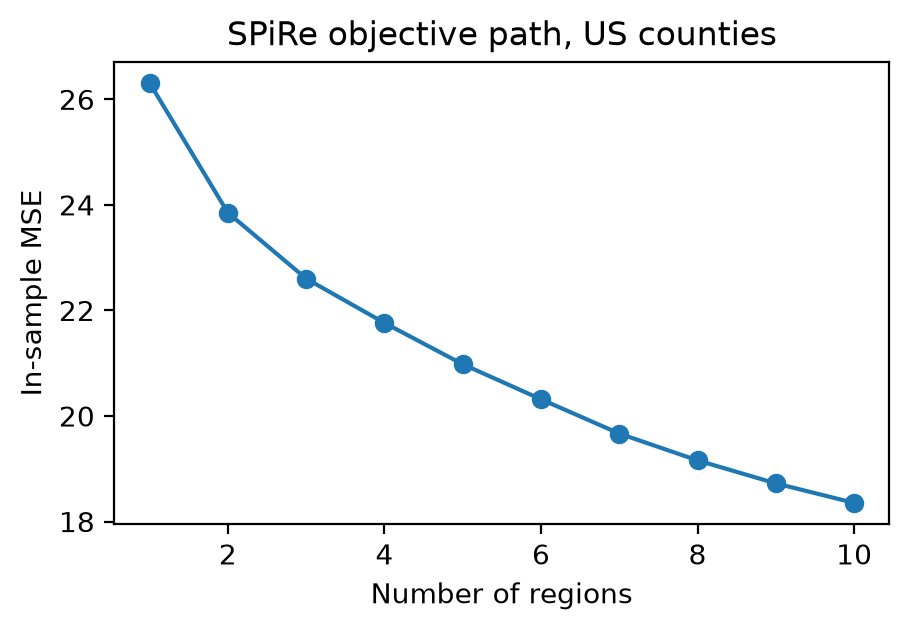

In [9]:
spire_us = Spire(
    counties,
    w_counties,
    predictors,
    "HR90",
    n_clusters=10,
    floor=60,
    random_state=0,
)
spire_us.solve()

fig, ax = plt.subplots(figsize=(5, 3))
n_regions = numpy.arange(1, len(spire_us.objective_path_) + 1)
ax.plot(n_regions, spire_us.objective_path_, marker="o")
ax.set_xlabel("Number of regions")
ax.set_ylabel("In-sample MSE")
ax.set_title("SPiRe objective path, US counties");

The error falls fastest over the first few regions and more slowly afterwards,
without a sharp elbow. As in the original paper, we use seven regions as a
compromise between fit and interpretability, solving again with
`n_clusters=7` to obtain the regional models. For comparison, SKATER partitions
the same counties using the predictors and the response as attributes.

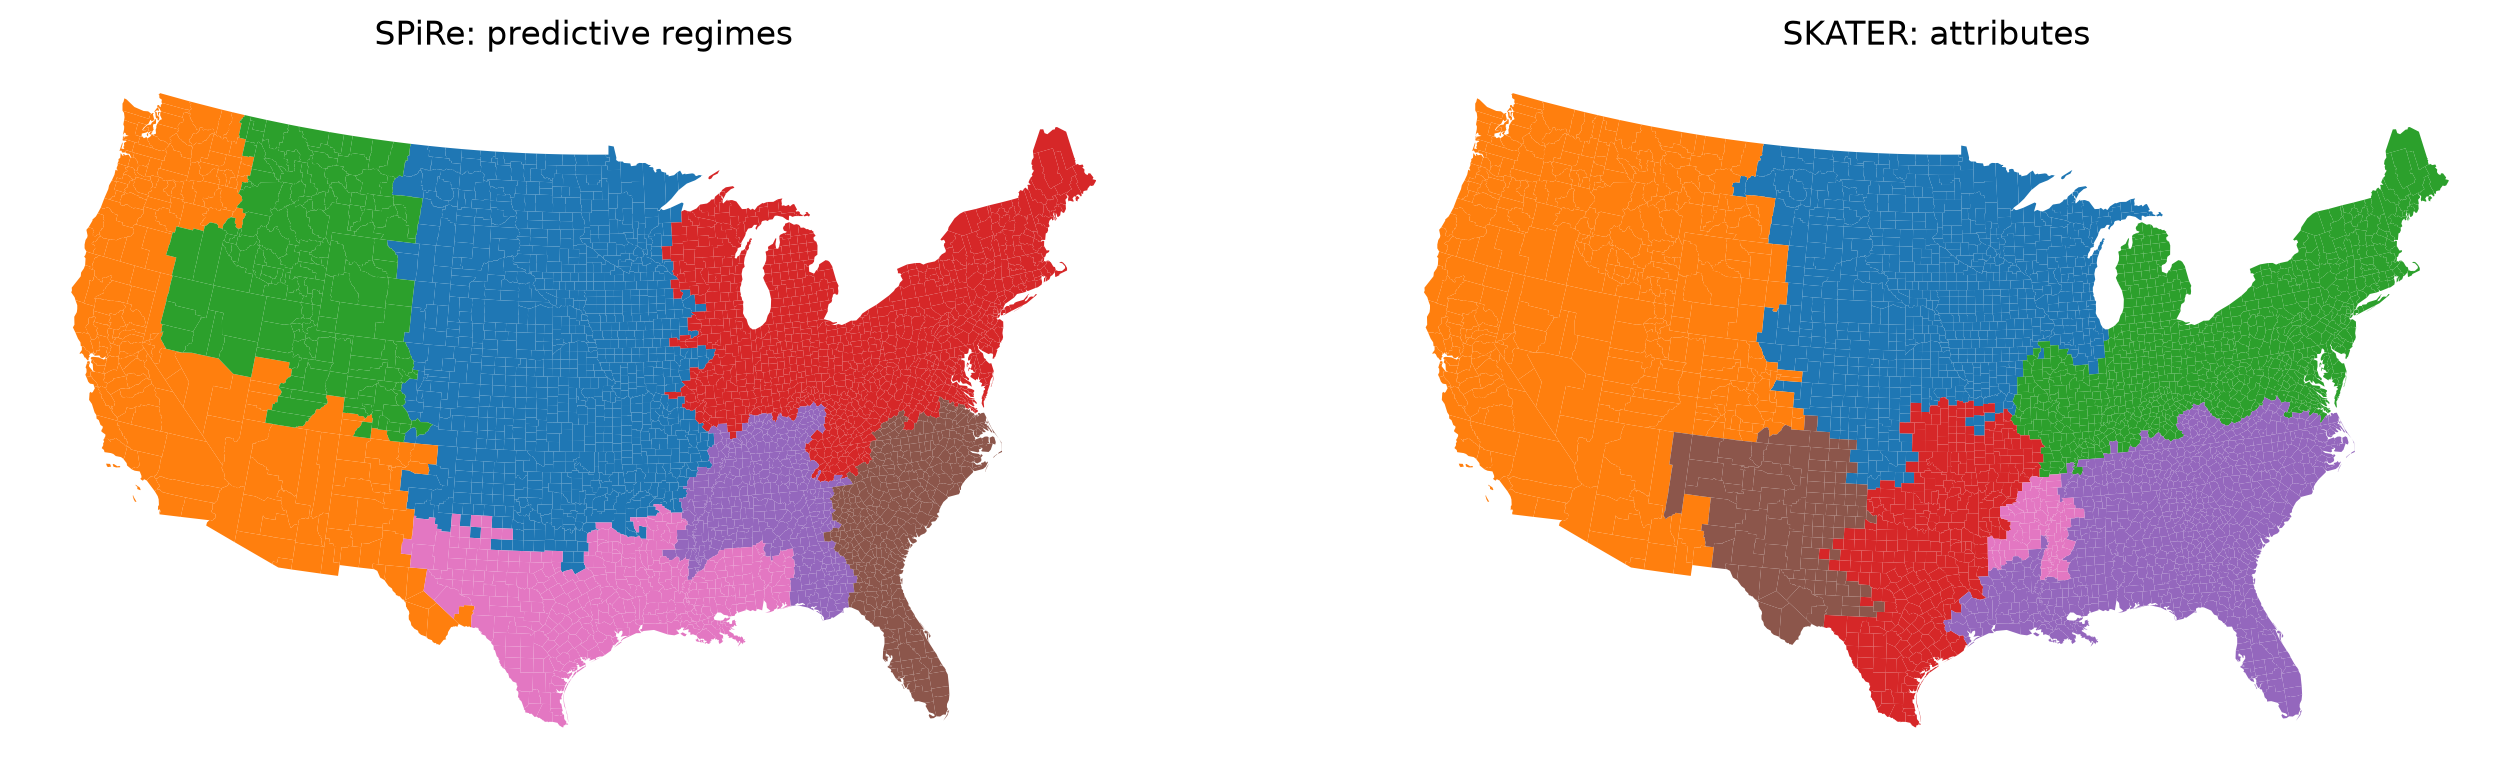

In [10]:
spire_us7 = Spire(
    counties,
    w_counties,
    predictors,
    "HR90",
    n_clusters=7,
    floor=60,
    random_state=0,
)
spire_us7.solve()
counties["spire"] = spire_us7.labels_

skater_us = Skater(counties, w_counties, [*predictors, "HR90"], n_clusters=7, floor=60)
skater_us.solve()
counties["skater"] = skater_us.labels_

projected = counties.to_crs(5070)
fig, axs = plt.subplots(1, 2, figsize=(16, 5))
for ax, column, title in zip(
    axs,
    ["spire", "skater"],
    ["SPiRe: predictive regimes", "SKATER: attributes"],
    strict=True,
):
    projected.plot(column=column, categorical=True, cmap="tab10", linewidth=0, ax=ax)
    ax.set_title(title)
    ax.set_axis_off()

SPiRe produces broad, geographically coherent regimes: the West Coast and
Southwest, the Mountain West, the Plains and upper Midwest, the Great Lakes and
Northeast, Tennessee and Kentucky, the Southeast Atlantic and the Gulf South. SKATER's regions instead
follow gradients in the attributes themselves.

The regional models show *how* the regimes differ.

In [11]:
diagnostics = {}
for label, model in spire_us7.regional_models_.items():
    region = counties[counties["spire"] == label]
    predicted = model.predict(region[predictors].to_numpy())
    residual = region["HR90"] - predicted
    diagnostics[label] = {
        "counties": len(region),
        "main states": ", ".join(region["STATE_NAME"].value_counts().index[:3]),
        "MSE": (residual**2).mean(),
        "R2": 1
        - (residual**2).sum() / ((region["HR90"] - region["HR90"].mean()) ** 2).sum(),
        **dict(zip(predictors, model.feature_importances_, strict=True)),
    }
pandas.DataFrame(diagnostics).T.sort_index().infer_objects().round(2)

,counties,main states,MSE,R2,RD90,PS90,UE90,DV90,MA90
0,849,"Kansas, Missouri, Iowa",15.17,0.34,0.48,0.10,0.00,0.35,0.07
1,194,"California, Washington, Oregon",16.39,0.41,0.54,0.18,0.14,0.00,0.14
2,154,"Montana, Idaho, Colorado",34.16,0.39,0.08,0.06,0.00,0.31,0.55
3,879,"Ohio, Indiana, Illinois",11.38,0.56,0.58,0.42,0.00,0.00,0.00
4,338,"Tennessee, Kentucky, Georgia",22.48,0.54,0.75,0.10,0.08,0.03,0.04
5,341,"Georgia, North Carolina, Florida",26.16,0.39,0.74,0.06,0.00,0.16,0.04
6,330,"Texas, Louisiana, Mississippi",38.90,0.22,0.50,0.40,0.10,0.00,0.00


Resource deprivation (`RD90`) is the dominant predictor of homicide in most
regimes, but its weight varies across the country. In the Great Lakes and
Northeast and in the Gulf South, population structure (`PS90`) carries a large
share of the importance as well, while in the Plains the divorce rate (`DV90`)
matters. The Mountain West stands apart: there, median age (`MA90`) and divorce
rate dominate and resource deprivation plays almost no role. These are regions
that differ in their predictive mechanism, not merely in their covariate
levels.